# UNSW-NB15 — Task 1 EDA (redo, raw flow files)
Group 5 · CSE475 · Track 1 (GNN)

This notebook explores the **raw** UNSW-NB15 flow files (`UNSW-NB15_1.csv`–`_4.csv`, ~2.54M records),
replacing the earlier EDA that was mistakenly run on the pre-split training/testing CSVs. The raw files
carry `srcip`, `sport`, `dstip`, `dsport`, `Stime`, `Ltime` — required later for host/time split and
graph construction, which the pre-split files don't have.

This notebook is **exploratory only** — no dedup, no split, no scaling here. That happens in the Task 2
preprocessing notebook.

**GPU (Kaggle T4×2):** `cudf.pandas` + `cuml.accel` are loaded in the cell below, before any pandas/sklearn import — every pandas call and the PCA/TSNE/UMAP calls in section G run on GPU with zero code changes elsewhere in this notebook, falling back to CPU automatically wherever something isn't GPU-supported (or if RAPIDS isn't present at all).

In [6]:
# --- GPU acceleration setup (Kaggle: Settings > Accelerator > GPU T4 x2, Environment > Always use latest environment) ---
# Must run first, before any pandas/sklearn import below.
#   cudf.pandas  -> GPU-accelerates every pandas call in this notebook (load, groupby, corr, describe, sample, ...)
#   cuml.accel   -> GPU-accelerates sklearn's PCA/TSNE and umap-learn's UMAP in section G
# Both fall back to plain CPU pandas/sklearn per-operation whenever something isn't GPU-supported, and entirely
# if RAPIDS isn't installed in this environment - no other cell needs to change either way.
GPU = False
try:
    ip = get_ipython()
    ip.run_line_magic('load_ext', 'cudf.pandas')
    ip.run_line_magic('load_ext', 'cuml.accel')
    GPU = True
except Exception as e:
    print(f"[GPU] RAPIDS extensions not loaded ({e})")
    print("[GPU] Check Settings > Accelerator = 'GPU T4 x2' and Environment preferences = 'Always use latest "
          "environment', then Factory Reset the session.")
    print("[GPU] Notebook still runs correctly on CPU pandas/sklearn below either way.")

print(f"[GPU] cudf.pandas + cuml.accel active: {GPU}")
!nvidia-smi --query-gpu=index,name,memory.total,memory.used,utilization.gpu --format=csv 2>/dev/null || echo "nvidia-smi unavailable - no GPU attached to this session"

# This dataset (~2.54M rows x 49 cols, well under 1 GB in memory) fits a single T4's 16 GB with room to spare,
# so only GPU 0 is used - the 2nd T4 in the "x2" pool sits idle by design. Multi-GPU (dask-cudf/dask-cuda) only
# pays off at tens of millions of rows or heavy distributed joins, which this EDA doesn't need.


The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas
The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel
[GPU] cudf.pandas + cuml.accel active: True
index, name, memory.total [MiB], memory.used [MiB], utilization.gpu [%]
0, Tesla T4, 15360 MiB, 495 MiB, 0 %
1, Tesla T4, 15360 MiB, 3 MiB, 0 %


In [7]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

## 0. Setup — locate files, load feature schema, load + concat raw data

In [8]:
# Auto-detect the Kaggle input folder for this dataset (files may sit nested under it)
feat_hits = glob.glob('/kaggle/input/**/NUSW-NB15_features.csv', recursive=True)
if not feat_hits:
    raise FileNotFoundError("NUSW-NB15_features.csv not found under /kaggle/input — check dataset is attached")

DATA_DIR = os.path.dirname(feat_hits[0])
print("Using:", DATA_DIR)
print(os.listdir(DATA_DIR))

Using: /kaggle/input/datasets/shahiismyname/unsw-nb15
['UNSW-NB15_1.csv', 'UNSW-NB15_4.csv', 'UNSW-NB15_3.csv', 'UNSW-NB15_2.csv', 'NUSW-NB15_features.csv']


In [9]:
# Load feature schema — defines exact column names + declared type for the raw files
feat = pd.read_csv(os.path.join(DATA_DIR, 'NUSW-NB15_features.csv'), encoding='latin1')
feat.columns = [c.strip() for c in feat.columns]
feat['Name'] = feat['Name'].astype(str).str.strip().str.replace(' ', '', regex=False)
feat['Type'] = feat['Type'].astype(str).str.strip().str.lower()

col_names = feat['Name'].tolist()
print(f"{len(col_names)} columns expected:")
print(col_names)

49 columns expected:
['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label']


In [10]:
# Load and concatenate the 4 raw flow files (no header row in the raw CSVs)
raw_files = sorted(glob.glob(os.path.join(DATA_DIR, 'UNSW-NB15_[1-4].csv')))
print("Raw files:", raw_files)

dfs = []
for f in raw_files:
    d = pd.read_csv(f, header=None, names=col_names, low_memory=False)
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
del dfs
print("Combined shape:", df.shape)
df.head()

Raw files: ['/kaggle/input/datasets/shahiismyname/unsw-nb15/UNSW-NB15_1.csv', '/kaggle/input/datasets/shahiismyname/unsw-nb15/UNSW-NB15_2.csv', '/kaggle/input/datasets/shahiismyname/unsw-nb15/UNSW-NB15_3.csv', '/kaggle/input/datasets/shahiismyname/unsw-nb15/UNSW-NB15_4.csv']
Combined shape: (2540047, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,Sload,Dload,Spkts,Dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,Sjit,Djit,Stime,Ltime,Sintpkt,Dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,29,0,0,dns,500473.93750,621800.93750,2,2,0,0,0,0,66,82,0,0,0.00000,0.000000,1421927414,1421927414,0.017,0.013000,0.0,0.0,0.0,0,0,0.0,0.0,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,29,0,0,-,87676.08594,50480.17188,4,4,0,0,0,0,132,76,0,0,9.89101,10.682733,1421927414,1421927414,7.005,7.564333,0.0,0.0,0.0,0,0,0.0,0.0,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,29,0,0,dns,521894.53130,636282.37500,2,2,0,0,0,0,73,89,0,0,0.00000,0.000000,1421927414,1421927414,0.017,0.013000,0.0,0.0,0.0,0,0,0.0,0.0,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,29,0,0,dns,436724.56250,542597.18750,2,2,0,0,0,0,66,82,0,0,0.00000,0.000000,1421927414,1421927414,0.043,0.014000,0.0,0.0,0.0,0,0,0.0,0.0,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,29,0,0,dns,499572.25000,609067.56250,2,2,0,0,0,0,73,89,0,0,0.00000,0.000000,1421927414,1421927414,0.005,0.003000,0.0,0.0,0.0,0,0,0.0,0.0,0,7,9,1,1,1,1,1,NaN,0


### Clean `attack_cat` for exploration
Blank/NaN = normal traffic. Raw files also have inconsistent spacing/casing across category names
(e.g. `" Fuzzers"` vs `"Fuzzers"`, `"Backdoor"` vs `"Backdoors"`) — normalize before counting classes.

In [11]:
df['attack_cat'] = df['attack_cat'].astype(str).str.strip()
df['attack_cat'] = df['attack_cat'].replace({'nan': 'Normal', '': 'Normal'})
df['attack_cat'] = df['attack_cat'].str.replace(r'\s+', ' ', regex=True)

print(sorted(df['attack_cat'].unique()))

['Analysis', 'Backdoor', 'Backdoors', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [12]:
# Fix known casing/naming variants — extend this after reviewing the unique list above
cat_fix = {
    'Backdoor': 'Backdoors',
}
df['attack_cat'] = df['attack_cat'].replace(cat_fix)
df['Label'] = pd.to_numeric(df['Label'], errors='coerce')

print(df['attack_cat'].value_counts())

attack_cat
Normal            2218764
Generic            215481
Exploits            44525
Fuzzers             24246
DoS                 16353
Reconnaissance      13987
Analysis             2677
Backdoors            2329
Shellcode            1511
Worms                 174
Name: count, dtype: int64


## A. Summary table


In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

unique_hosts = pd.unique(pd.concat([df['srcip'], df['dstip']]))
vc = df['attack_cat'].value_counts()

summary = pd.DataFrame({
    'Metric': [
        'Dataset', 'Source', 'Application area', 'Total samples',
        'Number of classes (attack_cat)', 'Numeric features', 'Categorical features',
        'Unique hosts (srcip ∪ dstip)', 'Class balance (majority:minority)',
        '% missing (any column)', '% duplicate rows'
    ],
    'Value': [
        'UNSW-NB15', 'UNSW Canberra (IXIA PerfectStorm)', 'Network intrusion detection',
        len(df), df['attack_cat'].nunique(), len(num_cols), len(cat_cols),
        len(unique_hosts), f"{vc.max()}:{vc.min()}",
        f"{100 * df.isna().any(axis=1).mean():.2f}%",
        f"{100 * df.duplicated().mean():.2f}%",
    ]
})
summary

,Metric,Value
0,Dataset,UNSW-NB15
1,Source,UNSW Canberra (IXIA PerfectStorm)
2,Application area,Network intrusion detection
3,Total samples,2540047
4,Number of classes (attack_cat),10
5,Numeric features,40
6,Categorical features,9
7,Unique hosts (srcip ∪ dstip),49
8,Class balance (majority:minority),2218764:174
9,% missing (any column),57.20%


## B. Statistics — numeric columns

In [14]:
desc = df[num_cols].describe().T
desc['skew'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurt()

def iqr_outlier_pct(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return 100 * ((s < lo) | (s > hi)).mean()

desc['outlier_%'] = df[num_cols].apply(iqr_outlier_pct)
desc.sort_values('skew', ascending=False)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,outlier_%
dur,2540047.0,6.587916e-01,1.392493e+01,0.000000e+00,1.037000e-03,1.586100e-02,2.145545e-01,8.786638e+03,590.036391,371440.470936,17.767270
trans_depth,2540047.0,8.325318e-02,3.500045e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.720000e+02,148.640991,65406.520164,8.075520
sbytes,2540047.0,4.339600e+03,5.640599e+04,0.000000e+00,2.000000e+02,1.470000e+03,3.182000e+03,1.435577e+07,142.981858,24006.582106,11.336089
sloss,2540047.0,5.163921e+00,2.251707e+01,0.000000e+00,0.000000e+00,3.000000e+00,7.000000e+00,5.319000e+03,118.739427,18653.410296,8.025954
Djit,2540047.0,7.300755e+02,3.438558e+03,0.000000e+00,0.000000e+00,2.653561e+00,6.350857e+01,7.812211e+05,98.448415,19088.917383,16.297691
Sjit,2540047.0,1.589037e+03,1.691036e+04,0.000000e+00,0.000000e+00,1.912490e+01,4.137935e+02,1.483831e+06,47.651534,2602.245570,18.632057
ackdat,2540047.0,2.892880e-03,2.394668e-02,0.000000e+00,0.000000e+00,1.220000e-04,1.400000e-04,5.512234e+00,42.821570,4348.150358,4.933452
synack,2540047.0,3.287595e-03,2.593570e-02,0.000000e+00,0.000000e+00,4.830000e-04,5.540000e-04,4.525272e+00,40.538344,3287.745866,4.378580
tcprtt,2540047.0,6.180475e-03,4.615863e-02,0.000000e+00,0.000000e+00,6.130000e-04,7.020000e-04,1.003751e+01,32.556720,2516.211163,4.416099
Spkts,2540047.0,3.328884e+01,7.628388e+01,0.000000e+00,2.000000e+00,1.200000e+01,4.400000e+01,1.064600e+04,27.084605,2265.638438,5.617258


**Reading:** columns with |skew| > 2 (typically `sbytes`, `dbytes`, `Sload`, `Dload`, `dur`) are heavily
right-skewed with a large outlier share — expected for byte/duration counts, and the reason these need
scaling in Task 2 rather than being used raw.

## C. Data quality

In [15]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print("Columns with missing values:")
print(missing_pct)

dup_count = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_count} ({100 * dup_count / len(df):.2f}%)")

Columns with missing values:
is_ftp_login        56.293407
ct_flw_http_mthd    53.075593
dtype: float64

Duplicate rows: 480632 (18.92%)


In [16]:
# Near-constant columns (dominant value covers >99% of rows)
near_constant = []
for c in df.columns:
    top_freq = df[c].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq > 0.99:
        near_constant.append((c, round(top_freq, 4)))

print("Near-constant columns (>99% single value):")
for c, f in near_constant:
    print(f"  {c}: {f}")

Near-constant columns (>99% single value):
  is_sm_ips_ports: 0.9983


In [17]:
# Highly correlated numeric pairs
corr = df[num_cols].corr().abs()
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
              .stack()
              .sort_values(ascending=False))
high_corr_pairs = pairs[pairs > 0.9]
print("Highly correlated pairs (|r| > 0.9):")
print(high_corr_pairs)

Highly correlated pairs (|r| > 0.9):
Stime             Ltime               1.000000
swin              dwin                0.997207
dloss             Dpkts               0.992163
dbytes            dloss               0.991342
                  Dpkts               0.970808
ct_dst_ltm        ct_src_dport_ltm    0.960154
ct_srv_src        ct_srv_dst          0.956734
sbytes            sloss               0.953492
ct_srv_dst        ct_dst_src_ltm      0.951026
ct_src_ltm        ct_src_dport_ltm    0.945332
ct_srv_src        ct_dst_src_ltm      0.942175
ct_dst_ltm        ct_src_ltm          0.938519
tcprtt            synack              0.931305
ct_src_dport_ltm  ct_dst_sport_ltm    0.921490
tcprtt            ackdat              0.918899
ct_src_dport_ltm  ct_dst_src_ltm      0.910894
sttl              ct_state_ttl        0.906061
                  Label               0.904393
dtype: float64


**Reading:** near-constant columns add no separating signal and should be dropped before training
(Task 2 step). For each highly correlated pair, keep the one with higher correlation to `Label` and drop
the other — record the exact drop list here so it carries into the preprocessing notebook.

## D. Class balance

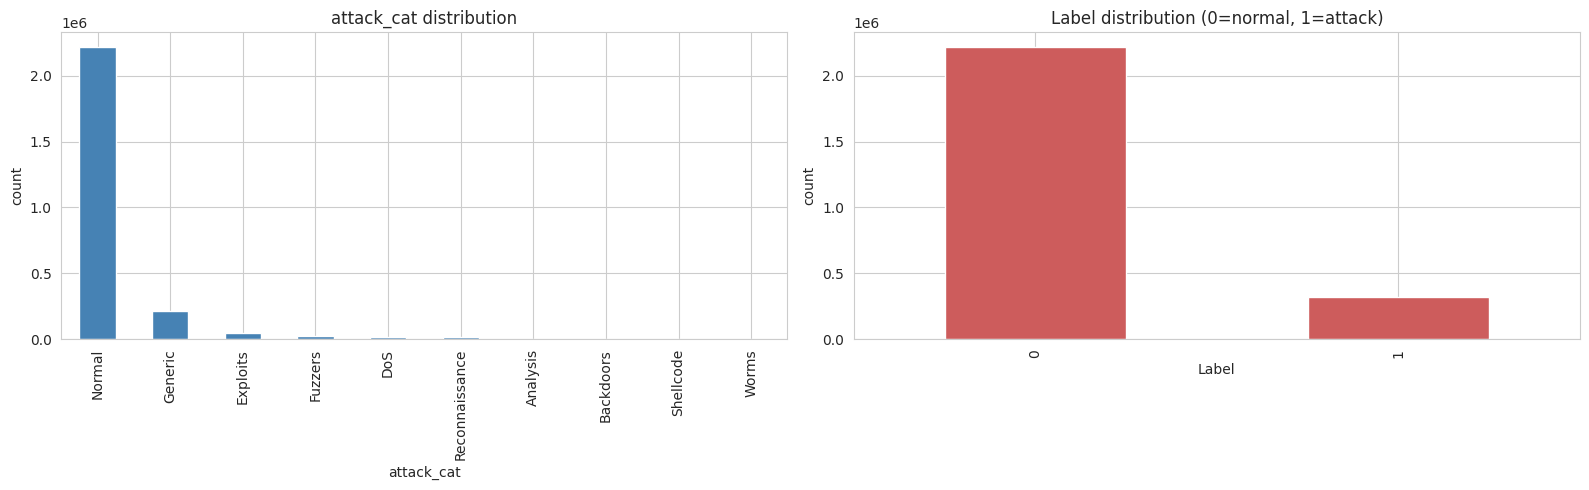

Majority:minority ratio = 12752:1


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['attack_cat'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('attack_cat distribution')
axes[0].set_ylabel('count')

df['Label'].value_counts().plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Label distribution (0=normal, 1=attack)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

ratio = df['attack_cat'].value_counts().max() / df['attack_cat'].value_counts().min()
print(f"Majority:minority ratio = {ratio:.0f}:1")

**Reading:** severe imbalance across attack categories (worst classes typically Worms/Shellcode/
Backdoors/Analysis) means overall accuracy is misleading — a model predicting the majority class for
everything scores high accuracy while missing every rare attack. Macro-F1 and per-class recall are the
metrics that actually reflect this, matching the course rubric's §6.2 requirement.

## E. Feature distributions

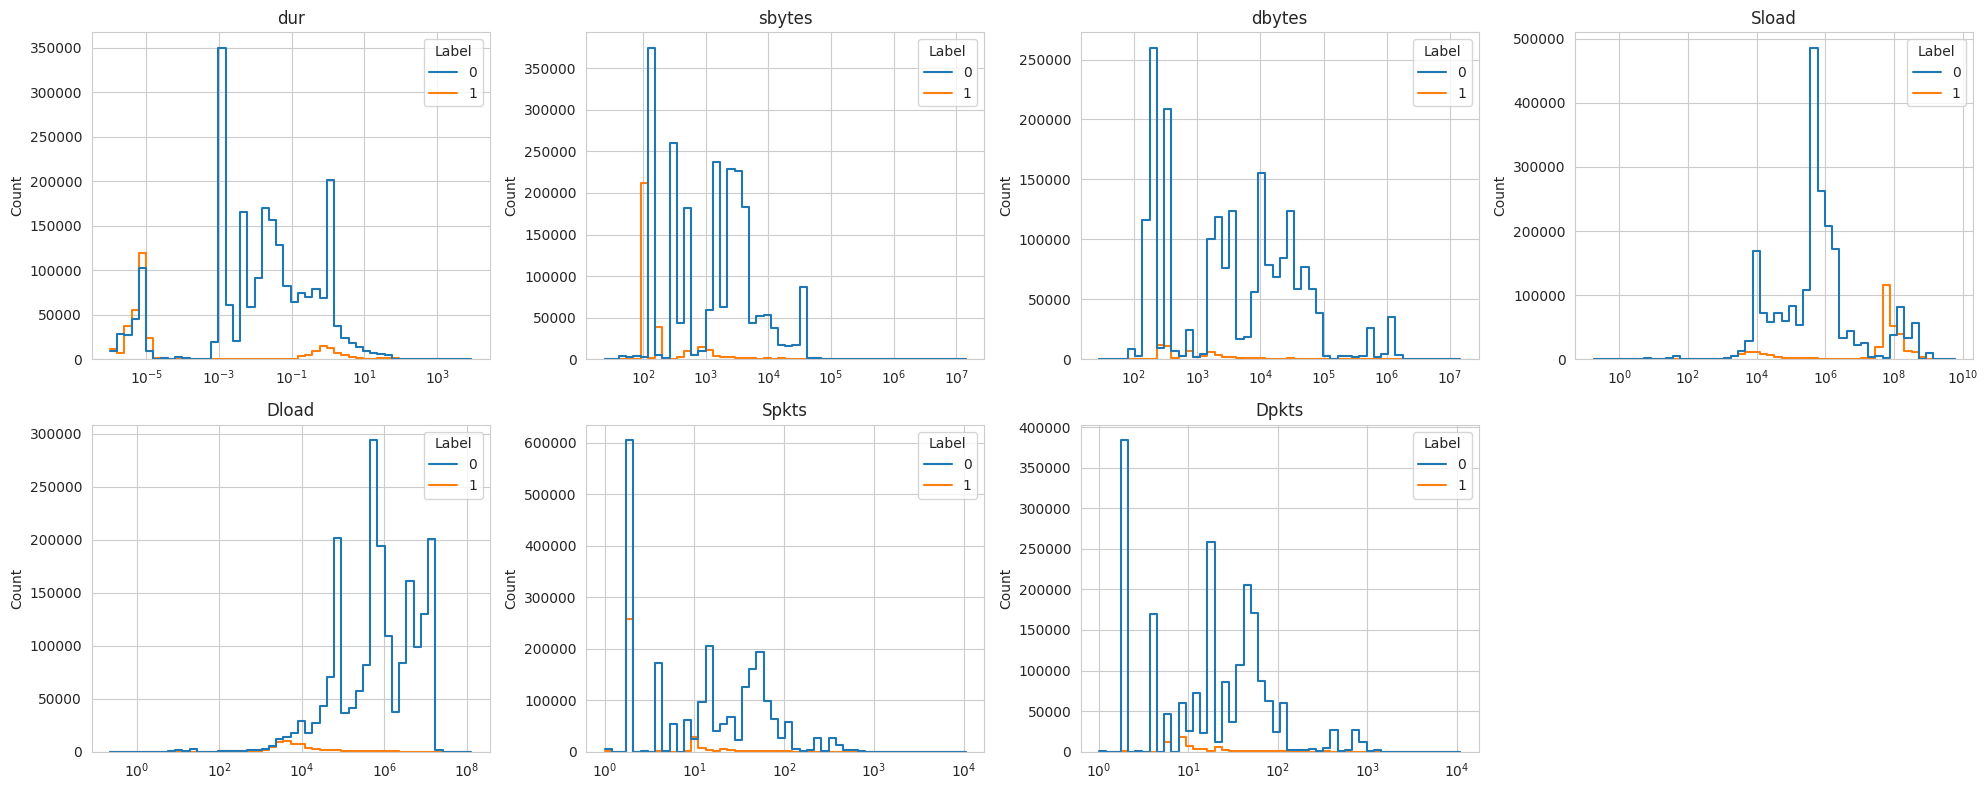

In [19]:
key_feats = ['dur', 'sbytes', 'dbytes', 'Sload', 'Dload', 'Spkts', 'Dpkts']
key_feats = [c for c in key_feats if c in df.columns]

# Under cudf.pandas, arrays pulled from a GPU-backed df stay tagged as proxy objects even after
# np.asarray() — seaborn's histplot(log_scale=..., element='step') fills the step area via
# matplotlib's fill_between(), which calls numpy.ma.masked_invalid() internally. That call does
# `result.mask = ...` on a fresh ndarray view, which breaks under the proxy -> AttributeError:
# 'numpy.ndarray' object has no attribute 'mask'. Two changes fix this for good:
#   1) np.array(..., copy=True) instead of np.asarray() — guarantees a genuinely detached numpy array
#      (asarray can no-op and hand back the same proxied object if it's already array-like).
#   2) fill=False — draws the step outline via ax.plot() instead of the filled area via
#      ax.fill_between(), which is what actually calls masked_invalid(). This is the fix that
#      matters; (1) is just a belt-and-suspenders extra.
label_arr = np.array(df['Label'], copy=True)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, c in enumerate(key_feats):
    x_arr = np.array(df[c], dtype=float, copy=True)
    sns.histplot(x=x_arr, hue=label_arr, bins=50, log_scale=(True, False),
                 element='step', fill=False, ax=axes[i])
    axes[i].set_title(c)
    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title('Label')
for j in range(len(key_feats), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

### Sampling for boxplot / violin plots
Boxplot/violin rendering on the full 2.54M-row frame draws one marker per IQR outlier — heavily right-skewed
columns (`sbytes`, `dbytes`, `Sload`, `dur`, ...) have a large outlier share, so this is slow and unreadable at
full scale. Use a random sample for these two plots only; the histograms above stay on the full data since
seaborn bins them into 50 bins regardless of N, so full-data histograms cost nothing extra.

In [20]:
plot_sample = df.sample(n=min(len(df), 200_000), random_state=42)
print("Plot sample size:", len(plot_sample))

Plot sample size: 200000


/usr/local/lib/python3.12/dist-packages/cudf/core/indexed_frame.py:3687: UserWarning: GPU-accelerated mergesort is currently not supported, defaulting to quicksort.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/cudf/core/indexed_frame.py:3687: UserWarning: GPU-accelerated mergesort is currently not supported, defaulting to quicksort.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/cudf/core/indexed_frame.py:3687: UserWarning: GPU-accelerated mergesort is currently not supported, defaulting to quicksort.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/cudf/core/indexed_frame.py:3687: UserWarning: GPU-accelerated mergesort is currently not supported, defaulting to quicksort.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/cudf/core/indexed_frame.py:3687: UserWarning: GPU-accelerated mergesort is currently not supported, defaulting to quicksort.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/cudf/core/indexed_frame.py:3687: UserWarning: GPU-

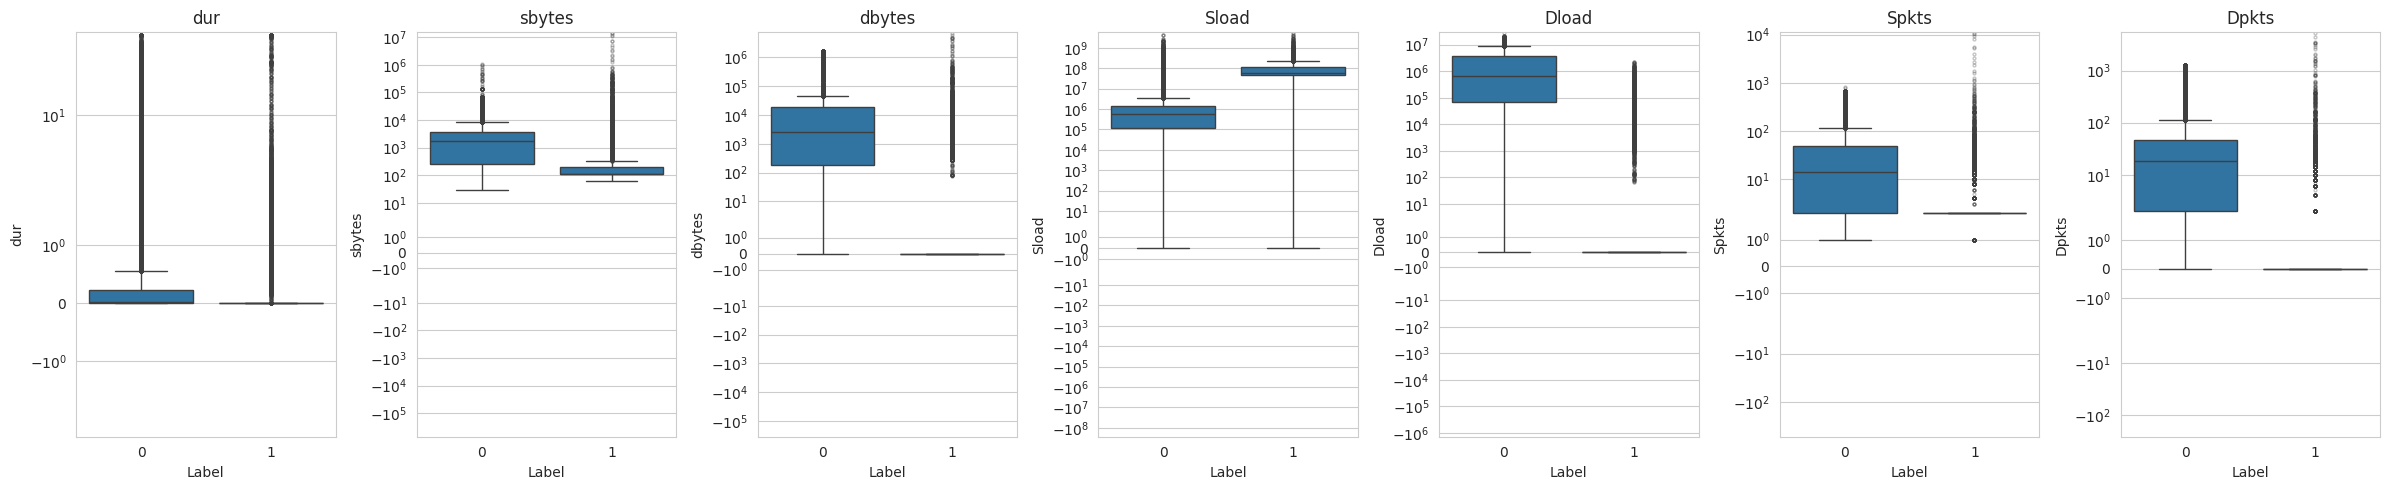

In [21]:
fig, axes = plt.subplots(1, len(key_feats), figsize=(24, 5))
for i, c in enumerate(key_feats):
    sns.boxplot(data=plot_sample, x='Label', y=c, ax=axes[i],
                flierprops=dict(markersize=2, alpha=0.3))
    axes[i].set_yscale('symlog')
    axes[i].set_title(c)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/cudf/core/indexed_frame.py:3687: UserWarning: GPU-accelerated mergesort is currently not supported, defaulting to quicksort.
  warnings.warn(


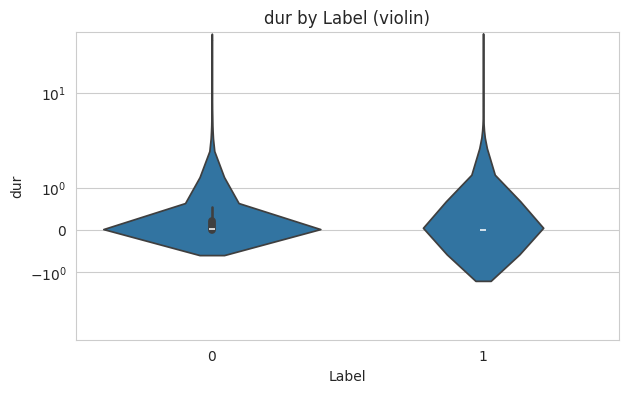

/usr/local/lib/python3.12/dist-packages/cudf/core/indexed_frame.py:3687: UserWarning: GPU-accelerated mergesort is currently not supported, defaulting to quicksort.
  warnings.warn(


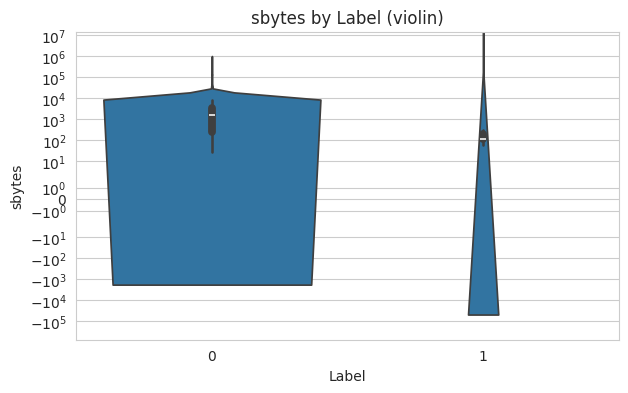

/usr/local/lib/python3.12/dist-packages/cudf/core/indexed_frame.py:3687: UserWarning: GPU-accelerated mergesort is currently not supported, defaulting to quicksort.
  warnings.warn(


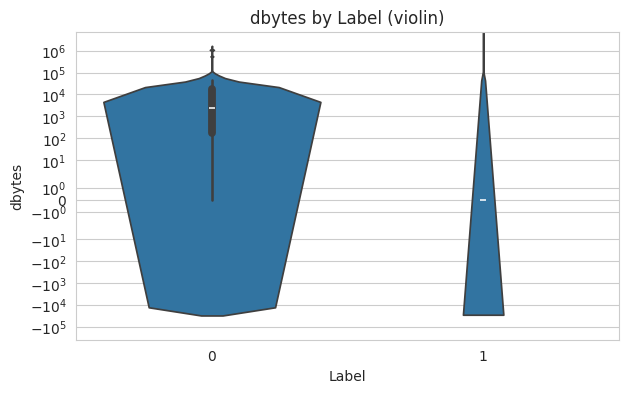

In [22]:
for c in key_feats[:3]:
    plt.figure(figsize=(7, 4))
    sns.violinplot(data=plot_sample, x='Label', y=c)
    plt.yscale('symlog')
    plt.title(f'{c} by Label (violin)')
    plt.show()

**Reading:** note which features visibly separate normal vs. attack traffic (usually `sbytes`, `dbytes`,
`Sload`) vs. which overlap heavily — the overlapping ones contribute less and are candidates for the
correlation/near-constant drop list from section C.

## F. Correlation heatmap

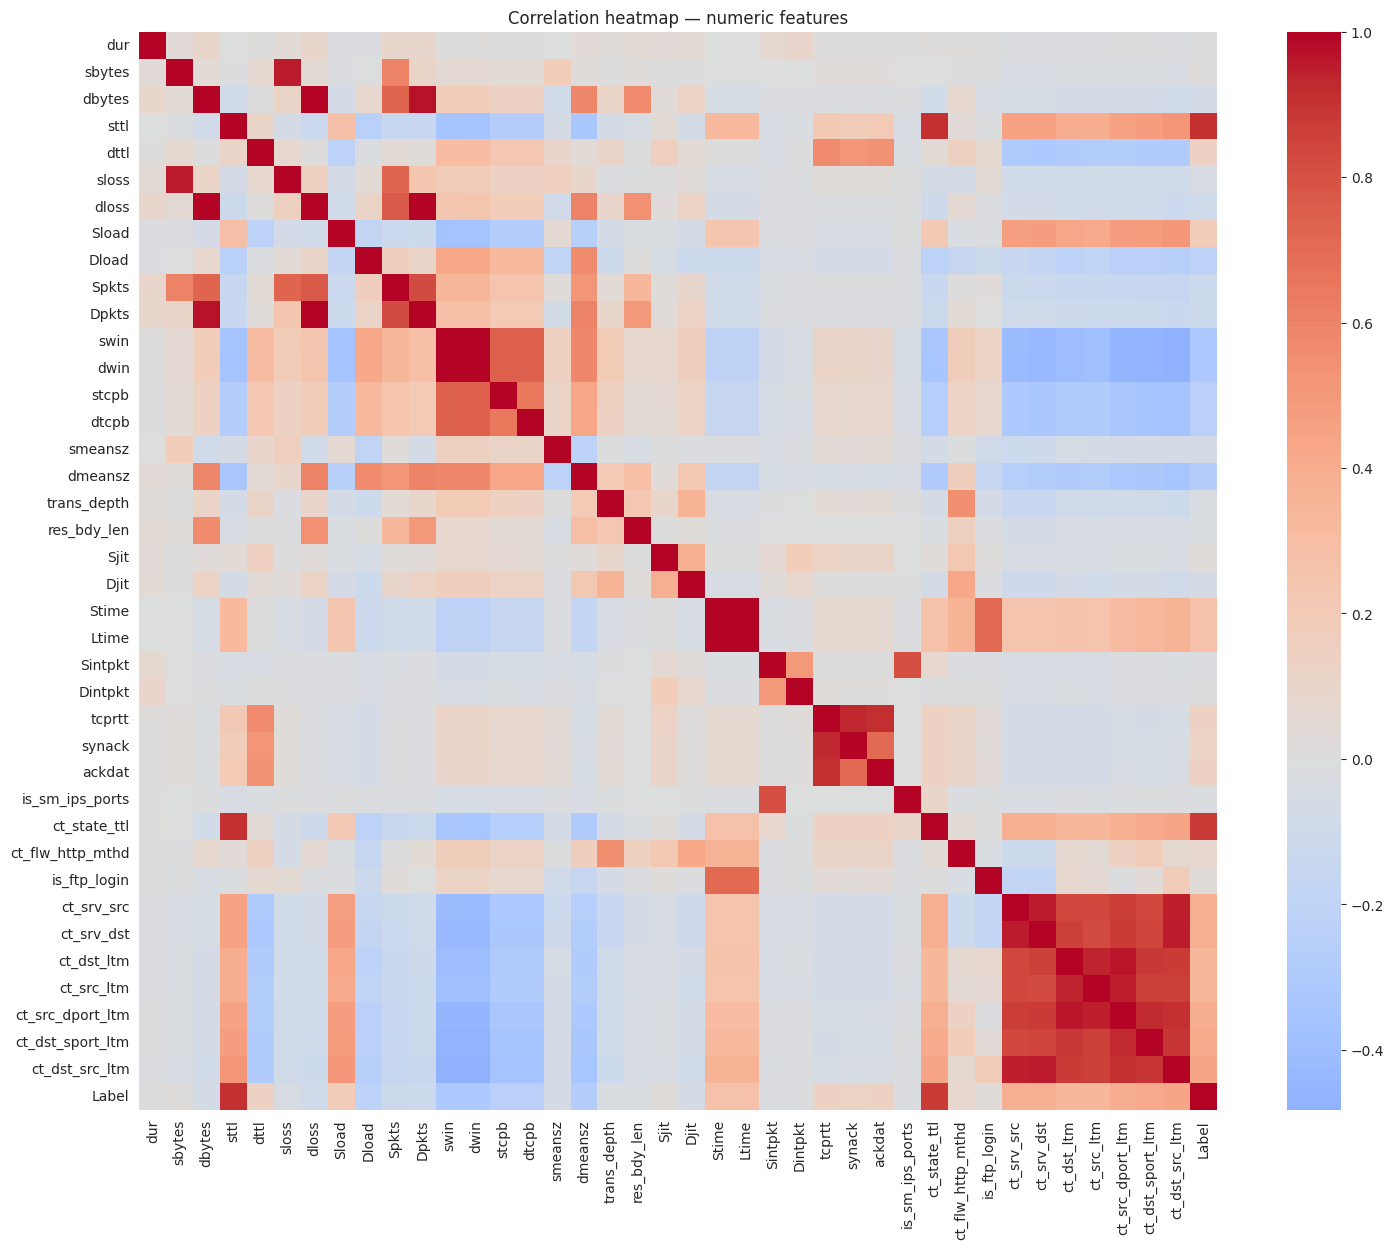

In [23]:
# Same GPU-proxy issue as the histograms in section E: sns.heatmap() masks NaNs internally via
# numpy.ma, which breaks if it's still holding a cudf.pandas-proxied object. Materialize the corr
# matrix to a plain detached numpy array (+ plain python list for labels) BEFORE handing it to
# seaborn, instead of passing the proxied DataFrame straight through.
corr_df = df[num_cols].corr()
corr_vals = np.array(corr_df, dtype=float, copy=True)
col_labels = list(corr_df.columns)

plt.figure(figsize=(18, 14))
sns.heatmap(corr_vals, cmap='coolwarm', center=0, square=True,
            xticklabels=col_labels, yticklabels=col_labels)
plt.title('Correlation heatmap — numeric features')
plt.show()

## G. Dimensionality reduction (PCA / t-SNE / UMAP)

In [24]:
# Section G needs sklearn's StandardScaler/PCA/TSNE - none were imported earlier in the notebook.
# cuml.accel (loaded in cell 1) transparently GPU-accelerates these exact sklearn calls with zero
# code changes, so we still just `from sklearn... import ...` normally here.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Explicit per-group loop instead of groupby().apply(lambda ...) - avoids the pandas "operating on the
# grouping column" FutureWarning and behaves identically across pandas versions. Runs under cudf.pandas too.
parts = [g.sample(n=min(len(g), 3000), random_state=42) for _, g in df.groupby('attack_cat')]
sample = pd.concat(parts, ignore_index=True)
print("Sample size:", len(sample))

X = sample[num_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

Sample size: 24691


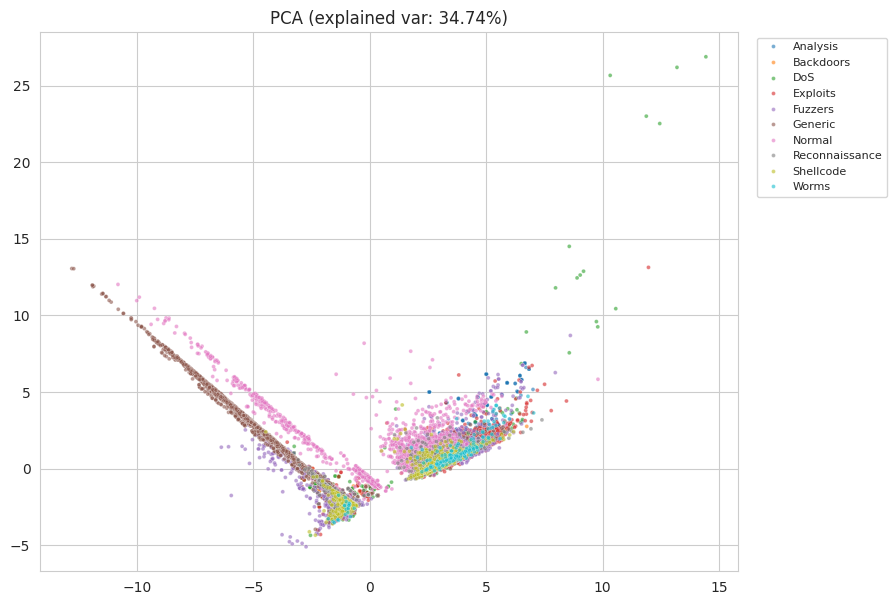

In [25]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=sample['attack_cat'], s=8, alpha=0.6)
plt.title(f'PCA (explained var: {pca.explained_variance_ratio_.sum():.2%})')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.show()

[2026-08-16 07:27:27.157] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


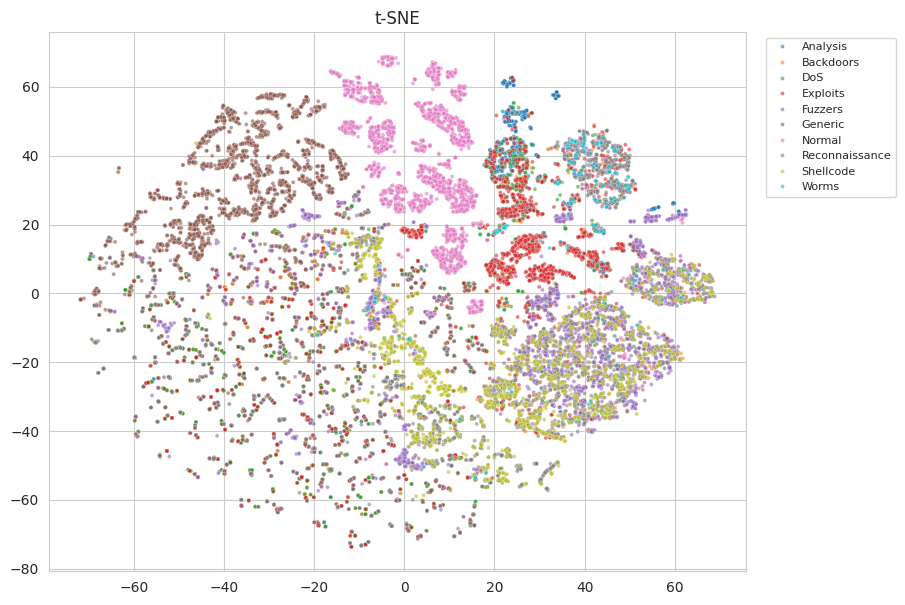

In [26]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=sample['attack_cat'], s=8, alpha=0.6)
plt.title('t-SNE')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.show()

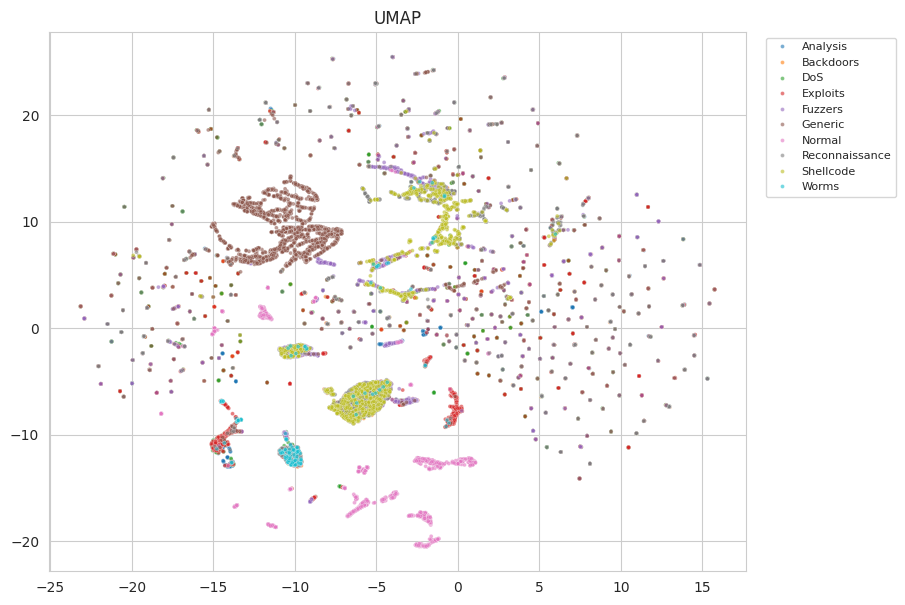

In [27]:
try:
    import umap
except ImportError:
    !pip install -q umap-learn
    import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=sample['attack_cat'], s=8, alpha=0.6)
plt.title('UMAP')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.show()

**Reading:** note which attack categories form visibly distinct clusters vs. which overlap with Normal
or with each other across all three projections — those are the classes the model will likely confuse,
worth calling out explicitly in the Task 1 report.

## H. Interactive plots

In [28]:
import plotly.express as px

vc_df = df['attack_cat'].value_counts().reset_index()
vc_df.columns = ['attack_cat', 'count']
fig = px.bar(vc_df, x='attack_cat', y='count', title='attack_cat distribution (interactive)',
             labels={'attack_cat': 'Attack category', 'count': 'Number of flows'})
fig.show()

In [29]:
fig = px.scatter(
    x=X_pca[:, 0], y=X_pca[:, 1], color=sample['attack_cat'],
    title='PCA components 1 vs 2, colored by attack_cat (interactive)',
    labels={'x': 'PC1', 'y': 'PC2'}
)
fig.show()

In [30]:
fig = px.box(sample, x='attack_cat', y='sbytes', log_y=True,
             title='sbytes by attack_cat (interactive, log scale)')
fig.show()

## Host count — for graph-construction feasibility

In [31]:
n_src = df['srcip'].nunique()
n_dst = df['dstip'].nunique()
n_hosts = pd.unique(pd.concat([df['srcip'], df['dstip']])).shape[0]

print(f"Unique srcip: {n_src}")
print(f"Unique dstip: {n_dst}")
print(f"Unique hosts (union): {n_hosts}")
print(f"Rows per host (avg): {len(df) / n_hosts:.1f}")

Unique srcip: 43
Unique dstip: 47
Unique hosts (union): 49
Rows per host (avg): 51837.7


**Reading:** if `n_hosts` is small relative to row count, the host graph will be hub-heavy with very
high-degree nodes — flag this for the graph-construction task (may favor IP:port-level nodes over raw
host-level nodes, or justify the hub structure explicitly in the Task 2 report).